# Deep learning
In this tutorial we will train convolutional neural network (CNN) classification models in Python. The following code requires tensorflow, pandas, and numpy. If you're running this on Anaconda's base environment (the setup this project expects), pandas and numpy are already installed. TensorFlow is the one exception — install it first with:

```
pip install tensorflow
```

If you're not using Anaconda, see the install instructions for [tensorflow](https://www.tensorflow.org/install/pip), [pandas](https://pandas.pydata.org/docs/getting_started/install.html), and [numpy](https://numpy.org/install/) instead.

## Directory Setup
To load the training and testing images,  the image directory structure needs a specific format, where the root directory (i.e. training directory) should contain subdirectories, and each subdirectory represents a distinct class (i.e. species). Each subdirectory should then contain the corresponding images belonging to that class. See the example below:

Training_Set/
    ├── Species_1/
    │   ├── Sp1_image1.jpg
    │   ├── Sp1_image2.jpg
    │   └── ...
    ├── Species_2/
    │   ├── Sp2_image1.jpg
    │   ├── Sp2_image2.jpg
    │   └── ...
    └── ...

The training and testing image sets need to be stored in separate directories, but must have the same structure.

## Model Training
### ResNet-50
For our first model, we will use the ResNet-50 architecture as the base to train a transfer-learned classification model. First, we must import the necessary modules.

In [10]:
from tensorflow.keras.applications.resnet50 import preprocess_input, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Model
import tensorflow as tf
import numpy as np
import random
import os

Here we are initializing our image sizes, batch sizes, and image directories. All images will be resized to the specified image size (224×224 in this case). Setting the image size smaller will decrease the amount of information given to the model, but will make the model train more quickly. The opposite is true for larger images.

Batch size determines how many images will be propagated through the model at a time. Large batch sizes require more of your system's memory, and can take longer to train. You might need to change the batch size based on your hardware specifications.

Set `dataset_dir` to the folder under `Data/` that contains your `training/` and `testing/` subfolders — it's found relative to the repository itself, so this works no matter whose machine (or which folder) the repo is cloned into. Set `model_run_name` to a short, unique label for this training run (following whatever naming convention "Tim" has outlined) — everything this notebook saves (best weights, predictions, confusion matrix, classification report, model_info.json) will be written into a subfolder of `models_dir` named after `model_run_name`. To start a new run, you only need to change `model_run_name` and `dataset_dir`.

In [ ]:
img_height, img_width = (224,224)
batch_size = 128

model_run_name = "InHouse_0603_ResNet50_1"  # change this for every new training run

def find_repo_root(marker='Models'):
    """Walk upward from the current working directory until a folder containing
    `marker` (i.e. the repo's Models/ folder) is found, so paths below don't
    depend on whose machine this notebook is running on."""
    path = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(path, marker)):
            return path
        parent = os.path.dirname(path)
        if parent == path:
            return os.path.abspath(os.getcwd())
        path = parent
    return os.path.abspath(os.getcwd())

REPO_ROOT = find_repo_root()

dataset_dir = os.path.join(REPO_ROOT, "Data", "InHouse_June", "InHouse_0603")  # change this to point at a different Data/ subfolder
train_data_dir = os.path.join(dataset_dir, "training")
test_data_dir = os.path.join(dataset_dir, "testing")
models_dir = os.path.join(REPO_ROOT, "Models")

run_dir = os.path.join(models_dir, model_run_name)
os.makedirs(run_dir, exist_ok=True)
os.chdir(run_dir)


`ImageDataGenerator` will generate batches of images that are normalized using a preprocessing function and augmented to the user's specifications. Image augmentations can increase the effective size and diversity of the training set, which can lead to enhanced performance and a reduction in overfitting. To get the most benefit from image augmentation, the augmentation's should be carefully chosen to match changes that might be expected in real data. For example, adding a vertical flip augmentation might not make sense if your model is unlikely to encounter any images where the subject is upside down. Some common augmentations include: 
- Flipping
- Rotation
- Translation
- Scaling
- Shearing
- Gaussian noise
- Adjustments to brightness/contrast

Because the test image set is meant to simulate a real-life images unseen by the model, augmentations are not usually applied.

In [3]:
train_datagen = ImageDataGenerator(preprocessing_function = preprocess_input,
                                   shear_range = 0.2,
                                   horizontal_flip = True)

test_datagen = ImageDataGenerator(preprocessing_function = preprocess_input)

Within `ImageDataGenerator`, we will use `flow_from_directory`. This will read in batches directly from our image directory, opposed to `flow`, which would read images preloaded into the Python environment. This makes `flow_from_directory` more memory efficient.

Setting the seed within `flow_from_directory` makes the batches reproduceable, and setting `shuffle = True` for the training data can prevent the model from overfitting to sequences within the data (e.g. species 1 images appear first, then species 2, etc.).

In [13]:
train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    seed = 123,
    shuffle = True,
    class_mode = 'categorical')


test_generator = test_datagen.flow_from_directory(
    test_data_dir,
    target_size = (img_height, img_width),
    batch_size = batch_size,
    seed = 123,
    shuffle = False,
    class_mode = 'categorical')

Found 575 images belonging to 4 classes.
Found 142 images belonging to 4 classes.


This code sets the seed and ensures reproduceability for our model training. The training will work without this code, but the final model will be slighlty different each time.

In [14]:
seed_value= 321

os.environ['PYTHONHASHSEED']=str(seed_value)

random.seed(seed_value)

np.random.seed(seed_value)

tf.random.set_seed(seed_value)

Here we are defining our model architecture. As a base, we are using the ImageNet ResNet50, making this a transfer learning CNN. After this we add a global average pooling layer, one dense layer with ReLu activation, dropout layers before and after the dense layer, and a softmax classification layer (see the "**Custom CNN**" section for more information on these layers). 

We must also set the base layers as non-trainable so their weights are not modified.

`EarlyStopping` is used to automatically stop the training procedure when the model performance plateaus on the validation image set. This helps ensure the model is not trained for too short or too long. In this code, the model will stop training if the validation loss is not improved for 10 epochs. Early stopping can be set to monitor validation accuracy instead by setting `monitor='val_loss'` to `monitor='val_accuracy'`.
`ModelCheckpoint` is used in tandem with `EarlyStopping` to save the model using the weights from the best epoch.

The model is then compiled and ready to be fit to the data.

In [15]:
base_model = ResNet50(include_top = False, weights = 'imagenet')
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.2)(x) 
x = Dense(1024, activation = 'relu')(x)
x = Dropout(0.2)(x) 
predictions = Dense(train_generator.num_classes, activation = 'softmax')(x)
model = Model(inputs = base_model.input, outputs = predictions)

for layer in base_model.layers:
    layer.trainable = False

early_stopping = EarlyStopping(monitor='val_loss', patience=10)
checkpoint = ModelCheckpoint('best_weights_ResNet50.h5', monitor='val_loss', save_best_only=True)

model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

This code trains the model using data from `train_generator` over a maximum of 100 epochs. If the conditions for early stopping are met before 100 epochs, the model will halt training and revert back to the epoch at which early stopping metric reached its peak. It is also tested using the test data after every epoch, which allows you to monitor its progression.

In [10]:
history = model.fit(train_generator,
          epochs = 100,
          validation_data = test_generator,
          callbacks = [early_stopping, checkpoint])

Epoch 1/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 6s/step - accuracy: 0.3649 - loss: 2.8560

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 281s 7s/step - accuracy: 0.5039 - loss: 1.9522 - val_accuracy: 0.7011 - val_loss: 0.9520
Epoch 2/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 5s/step - accuracy: 0.6992 - loss: 0.9695

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 255s 7s/step - accuracy: 0.7162 - loss: 0.9099 - val_accuracy: 0.7588 - val_loss: 0.7800
Epoch 3/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 6s/step - accuracy: 0.7453 - loss: 0.7878

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 263s 7s/step - accuracy: 0.7582 - loss: 0.7666 - val_accuracy: 0.7984 - val_loss: 0.6599
Epoch 4/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 264s 7s/step - accuracy: 0.7996 - loss: 0.6354 - val_accuracy: 0.7709 - val_loss: 0.6775
Epoch 5/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 6s/step - accuracy: 0.8340 - loss: 0.5554

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 294s 8s/step - accuracy: 0.8126 - loss: 0.6133 - val_accuracy: 0.8053 - val_loss: 0.6199
Epoch 6/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 7s/step - accuracy: 0.8390 - loss: 0.5328

...

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 387s 10s/step - accuracy: 0.8460 - loss: 0.4832 - val_accuracy: 0.8183 - val_loss: 0.5859
Epoch 8/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 8s/step - accuracy: 0.8508 - loss: 0.4511

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 362s 10s/step - accuracy: 0.8538 - loss: 0.4581 - val_accuracy: 0.8338 - val_loss: 0.5489
Epoch 9/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 378s 10s/step - accuracy: 0.8672 - loss: 0.4286 - val_accuracy: 0.8277 - val_loss: 0.5816
Epoch 10/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 341s 9s/step - accuracy: 0.8726 - loss: 0.4003 - val_accuracy: 0.7890 - val_loss: 0.6340
Epoch 11/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 8s/step - accuracy: 0.8503 - loss: 0.4552

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 369s 10s/step - accuracy: 0.8588 - loss: 0.4365 - val_accuracy: 0.8441 - val_loss: 0.4965
Epoch 12/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 333s 9s/step - accuracy: 0.8633 - loss: 0.4139 - val_accuracy: 0.8071 - val_loss: 0.5923
Epoch 13/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 489s 14s/step - accuracy: 0.8899 - loss: 0.3546 - val_accuracy: 0.8208 - val_loss: 0.5408
Epoch 14/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 301s 8s/step - accuracy: 0.8867 - loss: 0.3413 - val_accuracy: 0.8174 - val_loss: 0.5343
Epoch 15/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 277s 7s/step - accuracy: 0.8871 - loss: 0.3375 - val_accuracy: 0.8372 - val_loss: 0.5127
Epoch 16/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 0s 5s/step - accuracy: 0.9071 - loss: 0.2706

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 250s 7s/step - accuracy: 0.9107 - loss: 0.2835 - val_accuracy: 0.8493 - val_loss: 0.4627
Epoch 17/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 255s 7s/step - accuracy: 0.9168 - loss: 0.2516 - val_accuracy: 0.8536 - val_loss: 0.4647
Epoch 18/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 259s 7s/step - accuracy: 0.9038 - loss: 0.2942 - val_accuracy: 0.8381 - val_loss: 0.5246
Epoch 19/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 254s 7s/step - accuracy: 0.9053 - loss: 0.2796 - val_accuracy: 0.8493 - val_loss: 0.4885
Epoch 20/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 251s 7s/step - accuracy: 0.9101 - loss: 0.2637 - val_accuracy: 0.8165 - val_loss: 0.5655
Epoch 21/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 255s 7s/step - accuracy: 0.9086 - loss: 0.2640 - val_accuracy: 0.8510 - val_loss: 0.4692

37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 262s 7s/step - accuracy: 0.9255 - loss: 0.2179 - val_accuracy: 0.8613 - val_loss: 0.4514
Epoch 23/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 262s 7s/step - accuracy: 0.9248 - loss: 0.2176 - val_accuracy: 0.8475 - val_loss: 0.4980
Epoch 24/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 209s 6s/step - accuracy: 0.9281 - loss: 0.2189 - val_accuracy: 0.8596 - val_loss: 0.4931
Epoch 25/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 197s 5s/step - accuracy: 0.9289 - loss: 0.2070 - val_accuracy: 0.8570 - val_loss: 0.4718
Epoch 26/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 199s 5s/step - accuracy: 0.9409 - loss: 0.1754 - val_accuracy: 0.8036 - val_loss: 0.6355
Epoch 27/100
37/37 â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â”â” 201s 6s/step - accuracy: 0.9181 - loss: 0.2308 - val_accuracy: 0.8424 - val_loss: 0.5138

After the model is trained, we can access its training history to plot its accuracy and loss progression across epochs. However, this is only possible in the Python environment the model was trained in, as the training history is not preserved when the model is saved to your computer's memory.

The following code requires matplotlib. If you do not yet have matplotlib installed, follow the instructions here: https://matplotlib.org/stable/users/installing/index.html

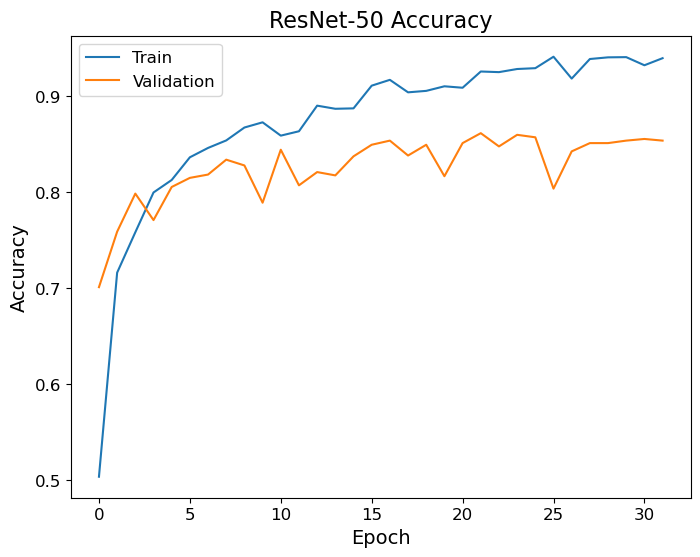

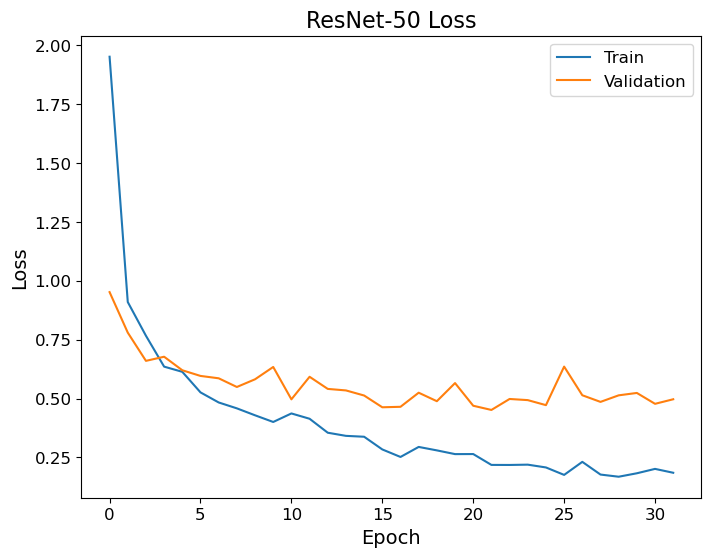

In [11]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.figure(figsize=(8, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('ResNet-50 Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(['Train', 'Validation'], loc='upper left', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.show()

# Plot loss
plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('ResNet-50 Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(['Train', 'Validation'], loc='upper right', fontsize=12)
plt.tick_params(axis='both', labelsize=12)
plt.show()

Finally, we can load the model saved by `ModelCheckpoint` to create a prediction probability matrix and export it as a .csv file.

In [ ]:
import pandas as pd
best_model = tf.keras.models.load_model(os.path.join(run_dir, "best_weights_ResNet50.h5"))
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

preds = model.predict(test_generator)
preddf = pd.DataFrame(preds)
preddf.to_csv("ResNet-Predictions.csv", index = False)

## Evaluation
After your model(s) has been trained and predictions have been made on a testing image set, we can measure the model's performance. The following code requires scikit-learn. If you do not yet have scikit-learn installed, follow the instructions here: https://scikit-learn.org/stable/install.html.

In [17]:
from sklearn.metrics import classification_report, roc_curve, precision_recall_curve, auc, confusion_matrix

First we will simply measure the accuracy and loss of the model.

In [21]:
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

valid_loss, valid_acc = best_model.evaluate(test_generator, verbose = 1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 35s 853ms/step - accuracy: 0.9296 - loss: 0.2009


Next, we will measure F1 score, precision, and recall.

In [22]:
# If you have not run created the `preds` object, do so using:
# np.random.seed(seed_value)
# tf.random.set_seed(seed_value)
# preds = best_model.predict(test_generator, verbose = 1)

predicted_classes = tf.argmax(preds, axis=1)

true_classes = test_generator.classes

report = classification_report(true_classes, 
                               predicted_classes, 
                               target_names=test_generator.class_indices,
                               output_dict=True)

macro_precision = report['macro avg']['precision']
macro_recall = report['macro avg']['recall']
macro_f1_score = report['macro avg']['f1-score']

Now we can measure top x accuracy (x = 3 in this example).

In [23]:
top_x = 3

predicted_indices = tf.argsort(preds, axis=1)[:, -top_x:]

top3_accuracy = np.mean(np.any(np.equal(predicted_indices, true_classes[:, np.newaxis]), axis=1))

Finally, we can generate a confusion matrix to visualize the distribution of classifications among out taxa.

In [24]:
conf_matrix = confusion_matrix(true_classes, predicted_classes)

We save the confusion matrix and classification report.

In [25]:
import pandas as pd

# Save confusion matrix
class_names = list(test_generator.class_indices.keys())
pd.DataFrame(conf_matrix, index=class_names, columns=class_names).to_csv("confusion_matrix.csv")

# Save classification report
pd.DataFrame(report).transpose().to_csv("classification_report.csv")

print("Saved confusion_matrix.csv and classification_report.csv")

Saved confusion_matrix.csv and classification_report.csv


Save training data info.

In [ ]:
import json

model_info = {
    "model": "ResNet50",
    "dataset": "InHouse_0603",
    "training_samples": {cls: int(list(train_generator.classes).count(idx)) for cls, idx in train_generator.class_indices.items()}
}

with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print("Saved model_info.json")

### Additional metrics
We can also make one-vs-rest ROC curves for each class.

In [ ]:
class_names = list(test_generator.class_indices.keys())

for class_name in class_names:
    class_index = test_generator.class_indices[class_name]
    class_predictions = preds[:, class_index]
    class_true_labels = (true_classes == class_index).astype(int)

    fpr, tpr, _ = roc_curve(class_true_labels, class_predictions)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label='ROC Curve (AUC = {:.2f})'.format(roc_auc))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - Class {}'.format(class_name))
    plt.legend(loc='lower right')
    plt.show()

We can also do the same for PR curves.

In [ ]:
class_names = list(test_generator.class_indices.keys())

for class_name in class_names:
    class_index = test_generator.class_indices[class_name]
    class_predictions = preds[:, class_index]
    class_true_labels = (true_classes == class_index).astype(int)

    precision, recall, _ = precision_recall_curve(class_true_labels, class_predictions)
    pr_auc = auc(recall, precision)

    plt.figure(figsize=(6, 4))
    plt.plot(recall, precision, label='PR Curve (AUC = {:.2f})'.format(pr_auc))
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve - Class {}'.format(class_name))
    plt.legend(loc='lower left')
    plt.show()